# Autoencoder Model For Raman Spectra

In [10]:
import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
import os

import processing as pr
import helpers as help
import structure as str

import torch
import torch.nn as nn

# Process Incoming Data File

In [11]:
# Access file
data = pr.read_txt("test.txt")
print(data[:, 0:5])
print(data.shape)
print('\n')

# Normalize intensity/amplitude vector
pr.normalize_vec(data[1, :])
print(data[:, 0:5])
print('\n')

# Set
cwd = os.getcwd()       # Change to folder with training data
set = pr.read_txt_bulk("test_list.txt", cwd)
print(set.shape)

[[  50.2494   52.3984   54.5469   56.6948   58.842 ]
 [2194.33   1902.51   1572.32   1849.27   2315.94  ]]
(2, 2097)


Intensity is normalized by dividing 3625.71.
[[50.2494   52.3984   54.5469   56.6948   58.842   ]
 [ 0.605213  0.524727  0.433658  0.510043  0.638754]]


Looking into /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/model
Accessing: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/model/test.txt
Accessing: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/model/test_copy.txt
Accessing: /Users/caozehuang/Documents/GitHub/Transformer-For-Spectral-Analysis/model/test_copy_2.txt
Number of dataset: 3
(4, 2097)


In [12]:
print(set[:, 0:10])

[[  50.2494   52.3984   54.5469   56.6948   58.842    60.9887   63.1333
    65.2788   67.4238   69.5681]
 [2194.33   1902.51   1572.32   1849.27   2315.94   2611.55   3223.67
  3463.57   3559.15   3606.76  ]
 [2194.33   1902.51   1572.32   1849.27   2315.94   2611.55   3223.67
  3463.57   3559.15   3606.76  ]
 [2194.33   1902.51   1572.32   1849.27   2315.94   2611.55   3223.67
  3463.57   3559.15   3606.76  ]]


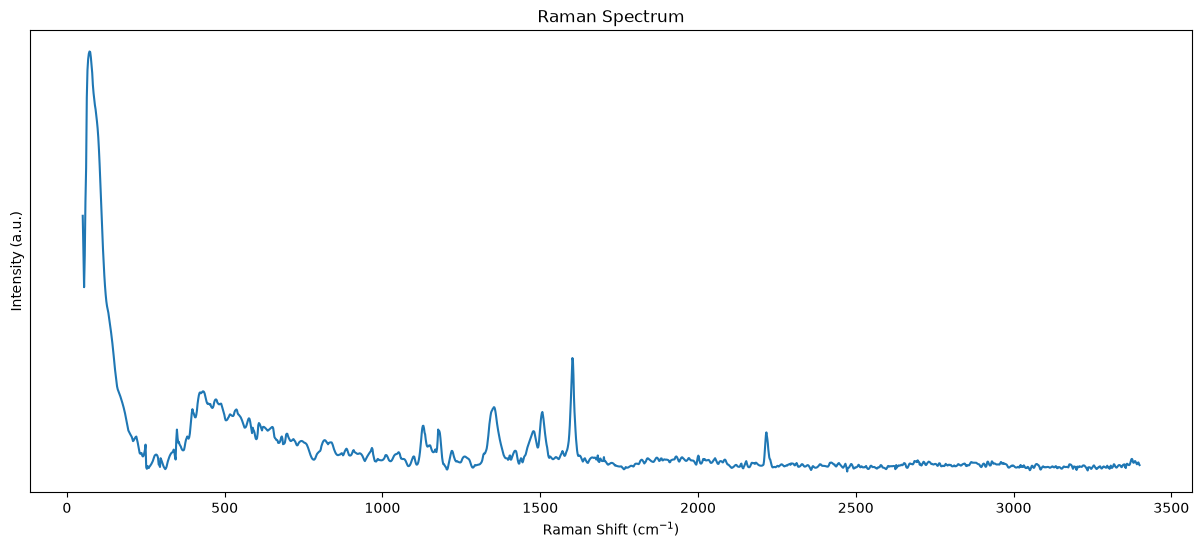

In [16]:
# Graph
x = data[0, :]
y = data[1, :]

# Plot
plt.figure(figsize=(15, 6))
plt.plot(x, y)

plt.yticks([])

plt.title("Raman Spectrum")
plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.show()

# Build Input Token Chain

In [14]:
# Break into patches/phrase
print(data.shape)
patch = pr.patch(data, 100)
print(patch.shape)

(2, 2097)
(21, 2, 100)


# Architecture

In [15]:
# Class Autoencoder
class AutoEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Structures are in structures.py
        self.encoder = str.Encoder()
        self.decoder = str.Decoder()

    def forward(self,x):

        z = self.encoder(x)

        x_hat = self.decoder(z)

        return x_hat

# Training

# Result and Comparison